In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [11]:
df = pd.read_csv("./data/train_metadata.csv")

In [12]:
df

,image_id,sun_azimuth_angle,label
0,train_00001.png,77.69,1
1,train_00002.png,75.97,1
2,train_00003.png,172.66,1
3,train_00004.png,150.14,1
4,train_00005.png,109.42,0
...,...,...,...
7849,train_07850.png,189.54,1
7850,train_07851.png,62.66,1
7851,train_07852.png,312.13,0
7852,train_07853.png,121.59,1


In [13]:
df["image_id"].nunique()

7854

In [14]:
df['label'].value_counts()

label
1    5000
0    2854
Name: count, dtype: int64

In [17]:
train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

[             image_id  sun_azimuth_angle  label
 5968  train_05969.png             153.83      1
 2400  train_02401.png             171.05      1
 5370  train_05371.png             275.42      1
 5525  train_05526.png             210.64      1
 3359  train_03360.png             162.75      1
 ...               ...                ...    ...
 2416  train_02417.png             306.16      1
 1245  train_01246.png             351.58      0
 1358  train_01359.png             312.53      0
 1948  train_01949.png             303.72      1
 3003  train_03004.png             322.84      0
 
 [6283 rows x 3 columns],
              image_id  sun_azimuth_angle  label
 1069  train_01070.png             296.29      1
 5929  train_05930.png             185.13      1
 7158  train_07159.png             100.46      1
 1241  train_01242.png             323.27      0
 2587  train_02588.png             120.24      1
 ...               ...                ...    ...
 6105  train_06106.png              29.39

### Testing out images

Size: (256, 256)
Angle: 77.69
Label: 1


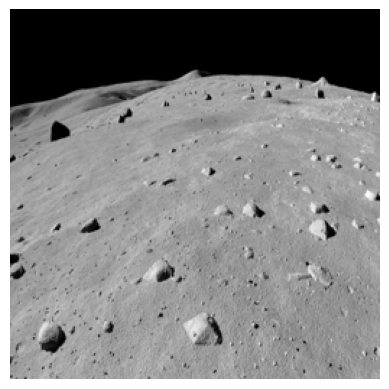

In [19]:
from PIL import Image
import matplotlib.pyplot as plt
import os

row = df.iloc[0]

image_path = os.path.join(
    "data/train_images",
    row["image_id"]
)

img = Image.open(image_path).convert("L")

print("Size:", img.size)
print("Angle:", row["sun_azimuth_angle"])
print("Label:", row["label"])

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [20]:
angle = row["sun_azimuth_angle"]

rotated = img.rotate(
    -angle,
    resample=Image.BICUBIC,
    expand=False
)

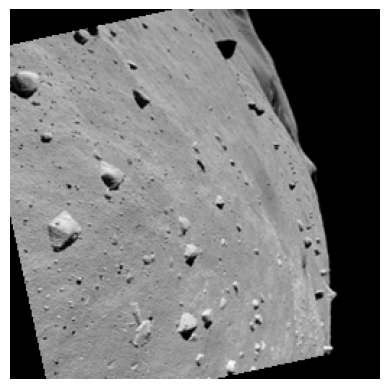

In [21]:
plt.imshow(rotated, cmap="gray")
plt.axis("off")
plt.show()

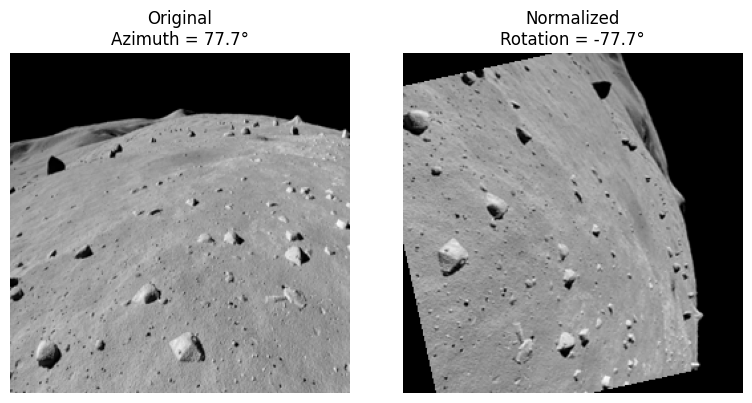

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title(
    f"Original\nAzimuth = {angle:.1f}°"
)
axes[0].axis("off")

axes[1].imshow(rotated, cmap="gray")
axes[1].set_title(
    f"Normalized\nRotation = {-angle:.1f}°"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

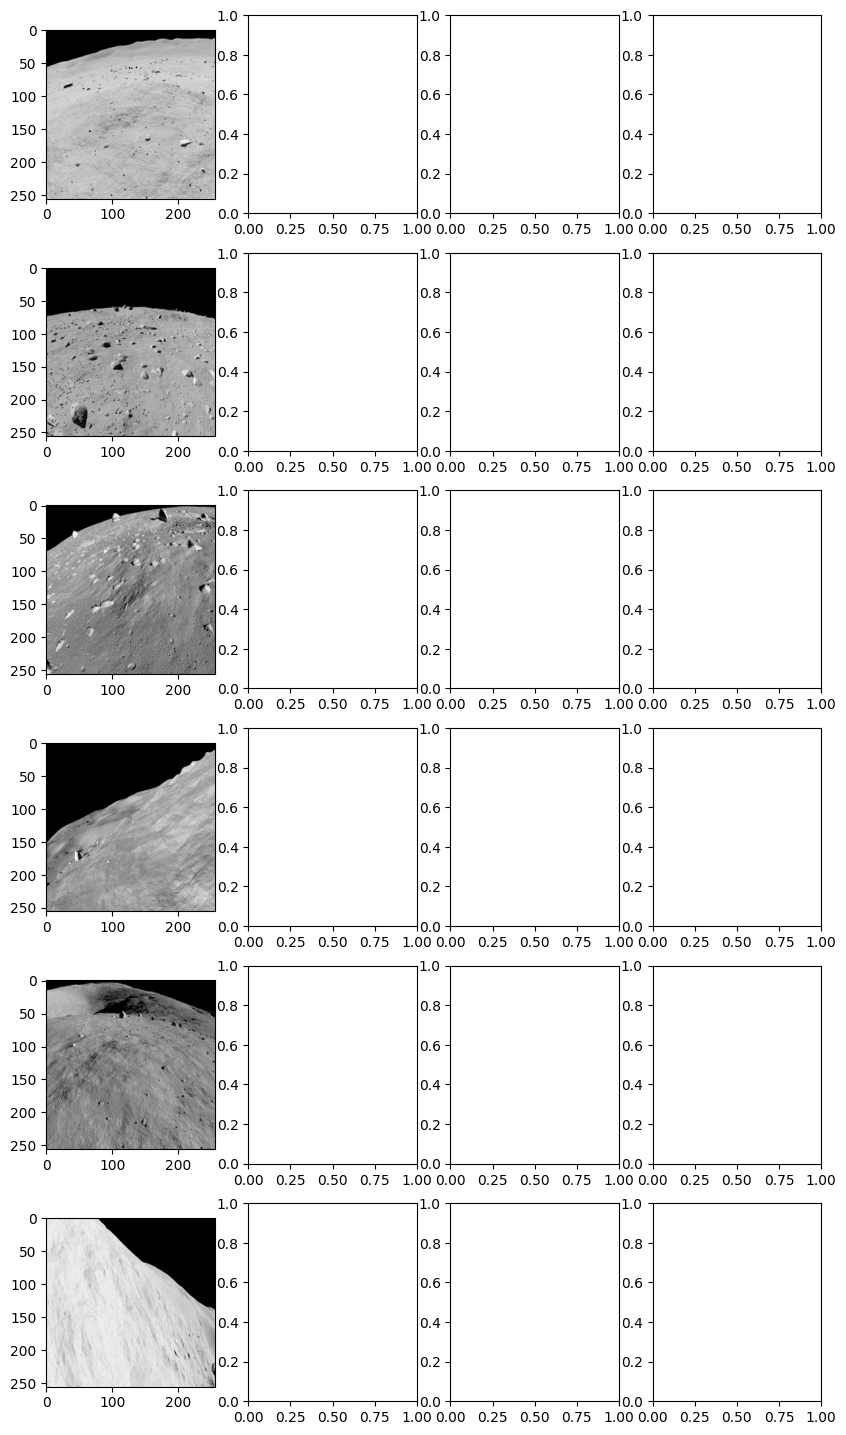

In [28]:
import random

indices = random.sample(range(len(df)), 12)

fig, axes = plt.subplots(
    6, 4,
    figsize=(10, 18)
)

for i, idx in enumerate(indices):

    row = df.iloc[idx]

    path = os.path.join(
        "data/train_images",
        row["image_id"]
    )

    img = Image.open(path).convert("L")

    angle = row["sun_azimuth_angle"]

    rotated = img.rotate(
        -angle,
        resample=Image.BICUBIC,
        expand=False
    )

    # Original
    axes[2*i//2, 0].imshow(img, cmap="gray")

    # axes[i//2, 0].imshow(rotated, cmap="gray")

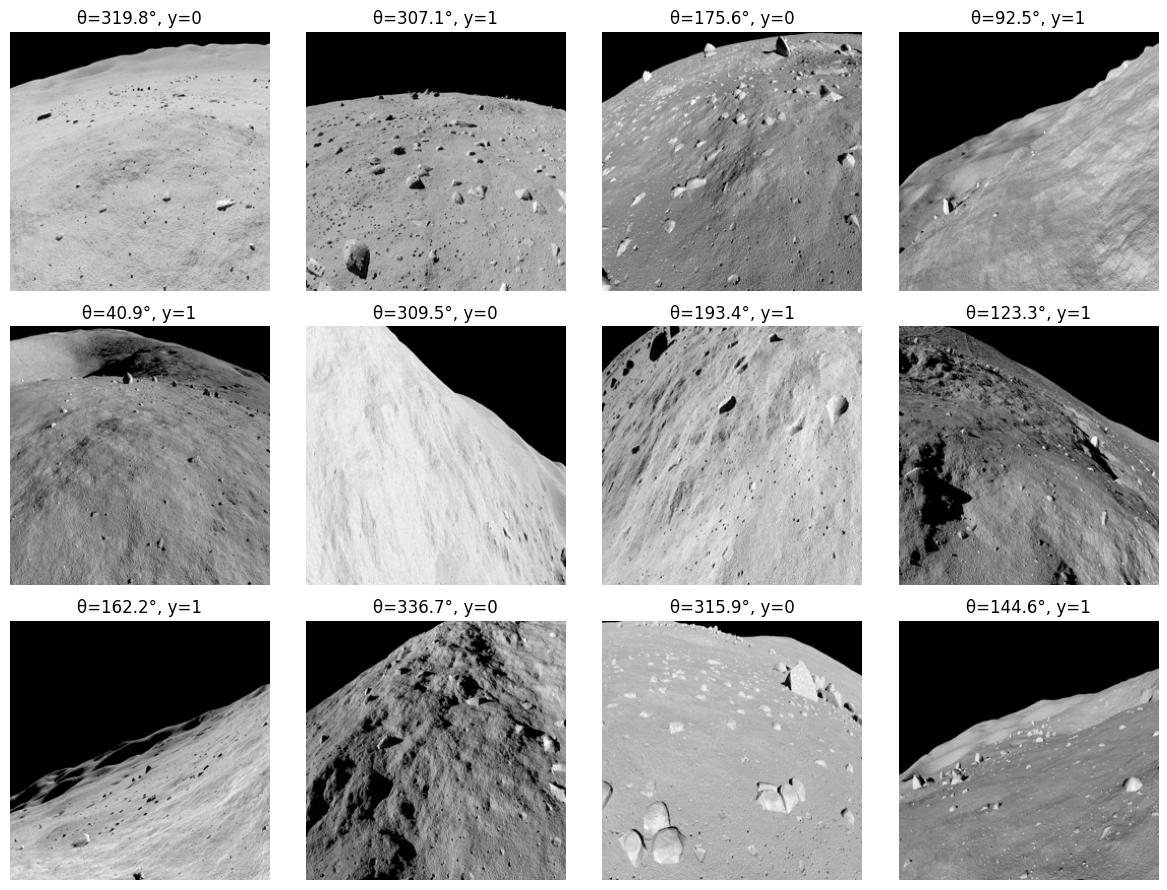

In [33]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, idx in zip(axes.flat, indices):

    row = df.iloc[idx]

    path = os.path.join(
        "data/train_images",
        row["image_id"]
    )

    img = Image.open(path).convert("L")

    ax.imshow(img, cmap="gray")

    ax.set_title(
        f"θ={row['sun_azimuth_angle']:.1f}°, "
        f"y={row['label']}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

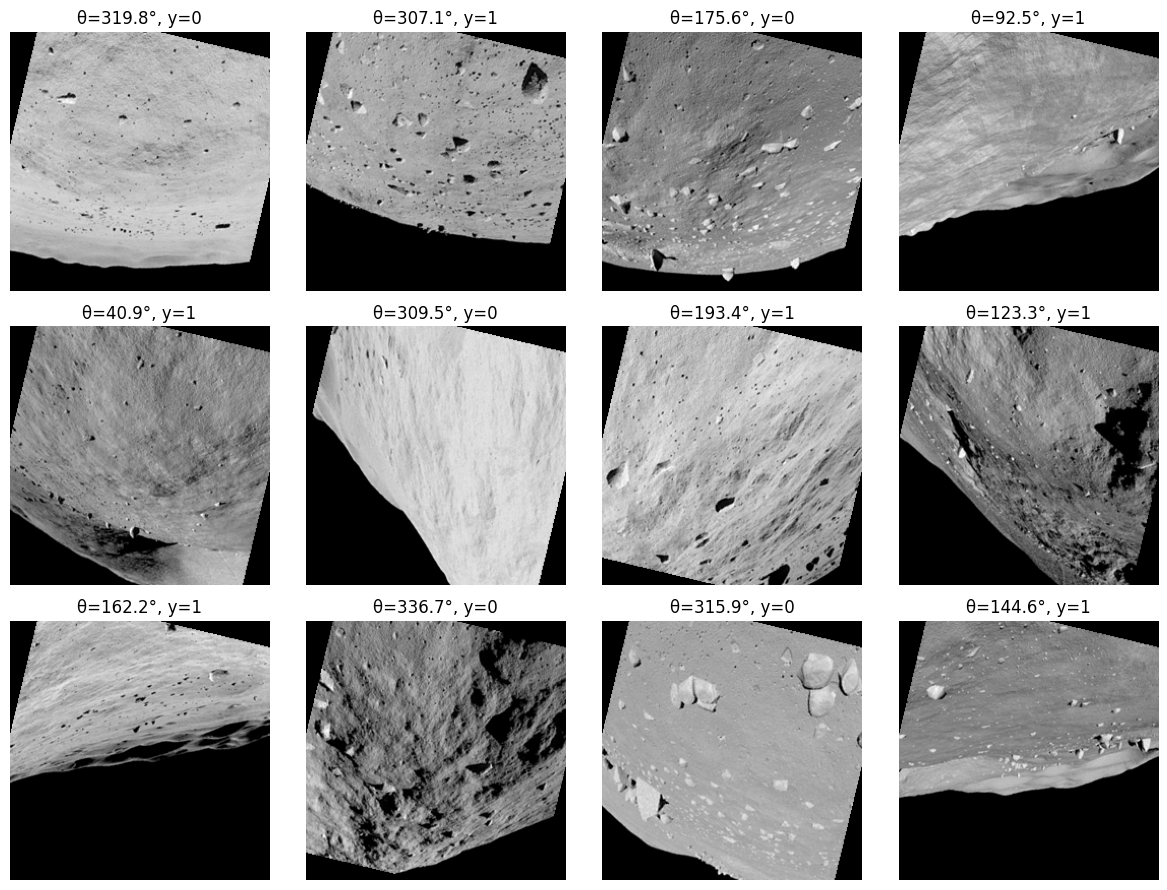

In [34]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, idx in zip(axes.flat, indices):

    row = df.iloc[idx]

    path = os.path.join(
        "data/train_images",
        row["image_id"]
    )

    img = Image.open(path).convert("L")
    rotated = img.rotate(
        -angle,
        resample=Image.BICUBIC,
        expand=False
    )

    ax.imshow(rotated, cmap="gray")

    ax.set_title(
        f"θ={row['sun_azimuth_angle']:.1f}°, "
        f"y={row['label']}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()